In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import sys

import seaborn as sns
import matplotlib.pyplot as plt

import torch

#Make sure to path to wherever sherlock is located
sys.path.append('../../..')
import sherlock as slk

/opt/conda/envs/perturb/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
slk.configs.reset_config()
slk.configs.show()
print('\n')
slk.configs.set_config('untreated_label', '0.0')
slk.configs.show()

ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = untreated


ntc_label       = NTC
pert_key        = pert
treatment_key   = treatment
untreated_label = 0.0


In [4]:
data = sc.read_h5ad("../../datasets/gbm/filtered_gbm_crispri_crop.h5ad")
data.obs.dose = data.obs.dose.astype(str)
slk.pp.slk_prepare_data(data, pert_key="gene_id", ntc_label="NTC", treatment_key='dose', untreated_label='0.0', inplace=True, force=True)

p_key = slk.configs.get_config('pert_key')
NTC   = slk.configs.get_config('ntc_label')
c_key = slk.configs.get_config('treatment_key')
c_ntc_key = slk.configs.get_config('untreated_label')

all_perts    = data.obs[p_key].unique()
print(f"Cells: {data.n_obs}   Genes: {data.n_vars}")
print(f"Single perts: {len(all_perts)}   NTC cells: {(data.obs[p_key]==NTC).sum()}")

all_conds = data.obs[c_key].unique()
print(f"Conditions: {all_conds}")
print(f"Condition counts:\n{data.obs[c_key].value_counts()}")
print(data.obs[data.obs[c_key] == c_ntc_key].shape)

Cells: 21429   Genes: 1758
Single perts: 101   NTC cells: 541
Conditions: ['0.5' '0.0' '0.25' '1.0']
Condition counts:
treatment
0.25    7200
0.0     5628
0.5     4720
1.0     3881
Name: count, dtype: int64
(5628, 47)


In [5]:
slk.pp.treat_effect(
    data,
    label_col = 'pert',
    control_label = 'NTC',
    method = "perturbseq",
    inplace=True,
    key='treat_effect'
)

100%|██████████| 100/100 [00:01<00:00, 73.12it/s]


Training VAE on cuda …


Epochs: 100%|██████████| 300/300 [04:19<00:00,  1.16it/s, ATE=0.1338, CE=0.0794, ELBO=1347.9334, KLw=1.00, R2_ntc=0.6111, R2_p=0.6399, acc=0.974, pi25=0.02, pi99=0.99, tau=0.300]


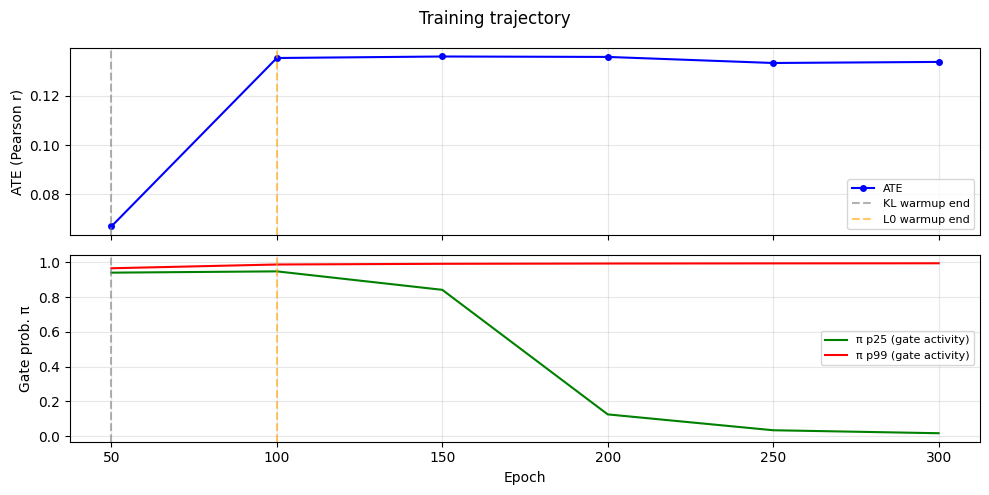

In [85]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = slk.tl.run_single(data, 
                            batch_size=4096,
                             num_workers=0, 
                             device=device, 
                             num_epochs=300,
                             use_conditions=True,
                             validate_every=50,
                             debug=True,
                            #  lr=1e-2,
                            #  gate_init_p=0.1
                             l0_lambda=40,
                             ce_lambda=1e2,
                             lr=1e-2,
                             patience=500,
                             rho_init=True,
                             ntc_lambda=1.0,
                             cov_lambda=1e-1,
                            #  prior_cond_ridge=1e-1
                            #  n_epochs_kl_warmup=10
                             )

In [ ]:
slk.tl.save_results(results, '../../results/gbm_cripsri.pth')

In [87]:
model = slk.tl.load_results('../../results/gbm_cripsri.pth')

In [88]:
slk.tl.eval_single(model, data, obsm_key="z", uns_key="results", device=device)
print(list(data.uns['results'].keys()))

['z_corr', 'z_perts', 'z_embed', 'rho_corr', 'rho_perts', 'rho_embed', 'acc', 'z_rho_corr', 'W', 'counterfactual_effect_size', 'condition_perturbation_interaction', 'conditions']


/home/jm5707/.local/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


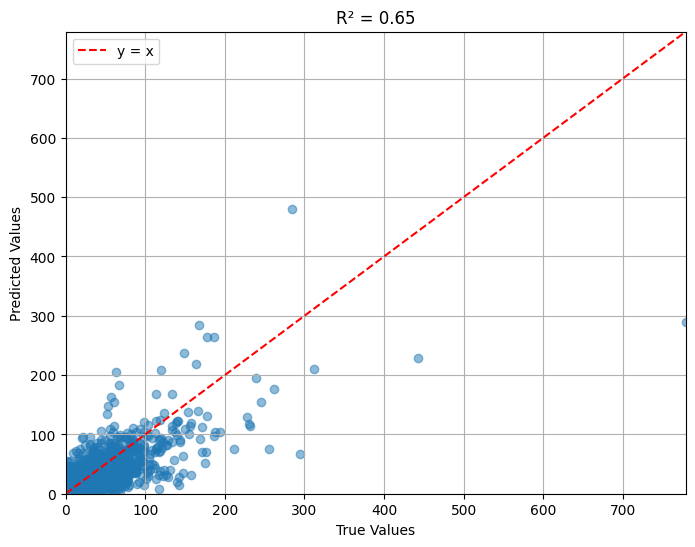

In [58]:
slk.pl.plot_r2(data)

/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/opt/conda/envs/perturb/lib/python3.10/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


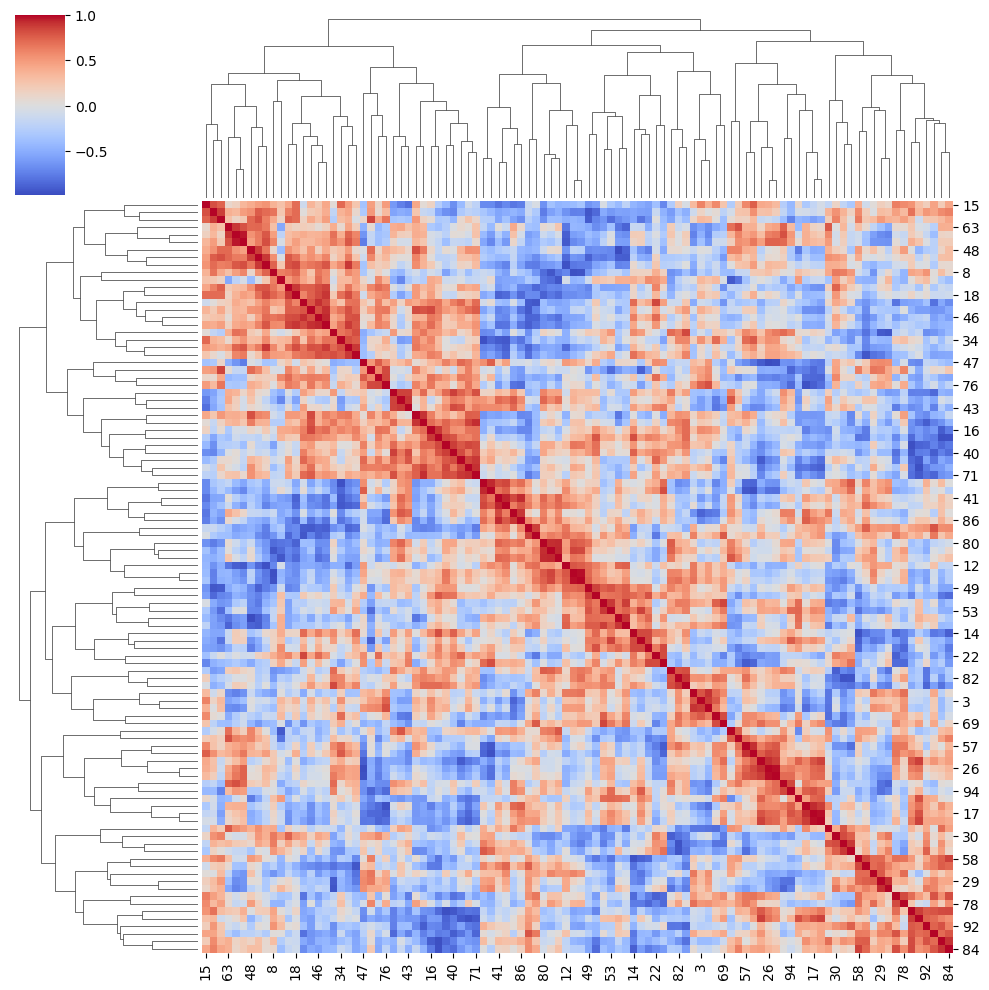

In [89]:
slk.pl.plot_corr(data)

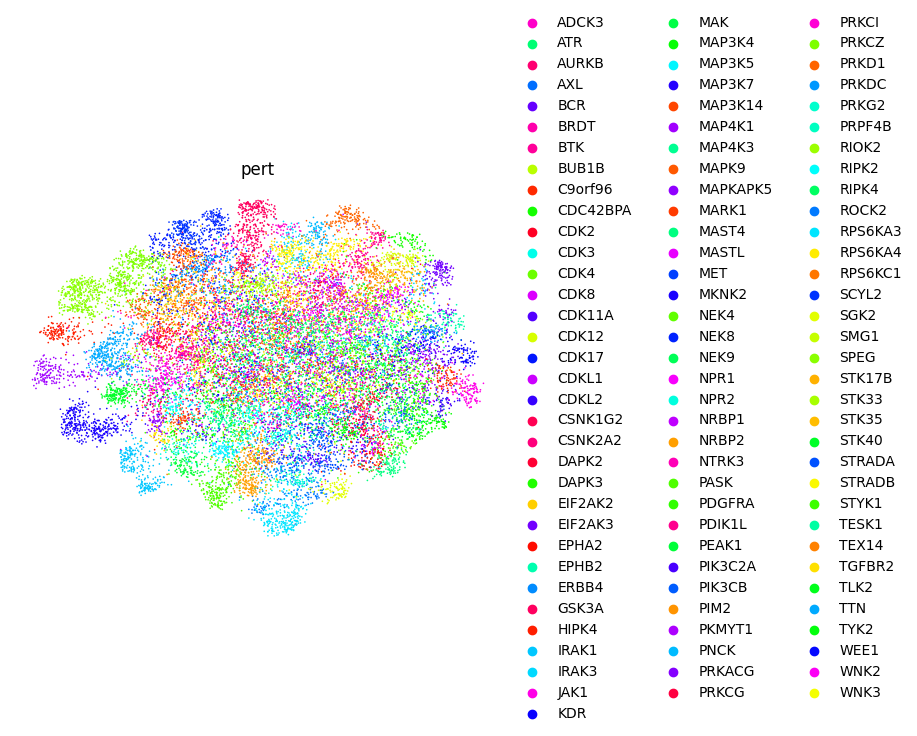

In [97]:
p_key = slk.configs.get_config('pert_key')
NTC = slk.configs.get_config('ntc_label')

sub = data[data.obs[p_key] != NTC]

sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

import random
n_cats = sub.obs[p_key].nunique()
palette = sns.color_palette("hsv", n_colors=n_cats)
random.shuffle(palette)
sc.pl.umap(sub, color='pert', palette=palette, frameon=False)

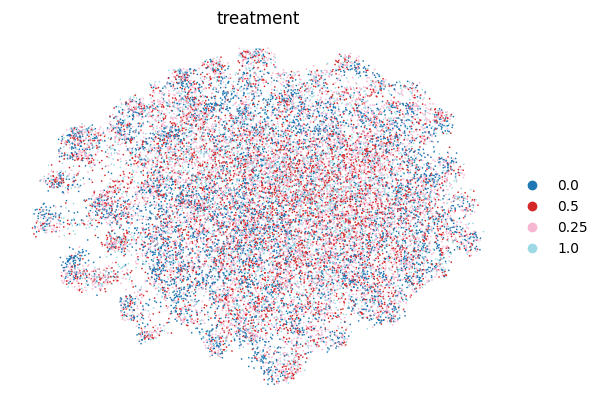

In [98]:
sc.pl.umap(sub, color='treatment', palette='tab20', frameon=False)

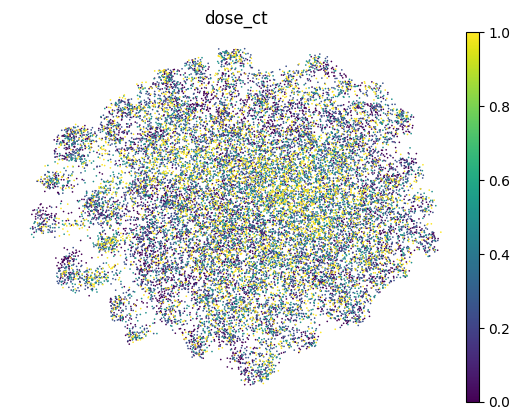

In [99]:
sub.obs['dose_ct'] = sub.obs.treatment.astype(float)
sc.pl.umap(sub, color='dose_ct', frameon=False)

In [90]:
from scipy.stats import pearsonr, spearmanr

z_corr   = data.uns['results']['z_corr']
rho_corr = data.uns['results']['rho_corr']

pearson  = pearsonr(z_corr.flatten(),  rho_corr.flatten())
spearman = spearmanr(z_corr.flatten(), rho_corr.flatten())
print(f"Spearman ρ = {spearman.statistic:.3f}  (p = {spearman.pvalue:.1e})")
print(f" Pearson  r = {pearson.statistic:.3f}  (p = {pearson.pvalue:.1e})")

Spearman ρ = 0.756  (p = 0.0e+00)
 Pearson  r = 0.763  (p = 0.0e+00)


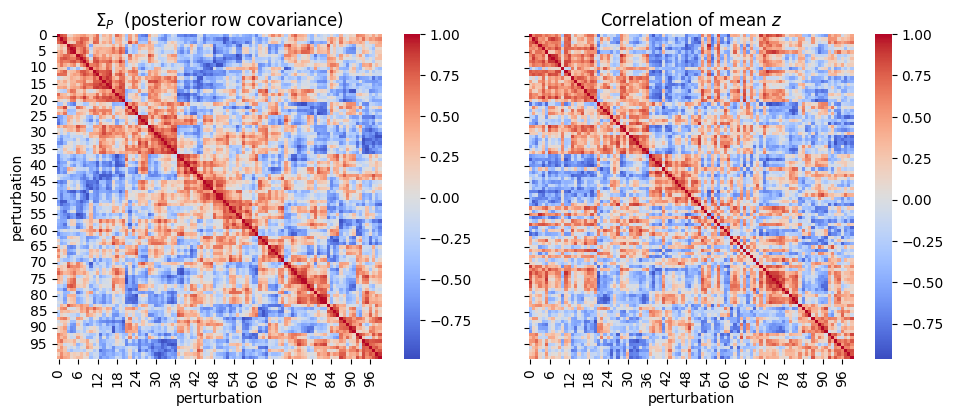

In [91]:
slk.pl.plot_zcorr(data)

W shape: (100, 16)


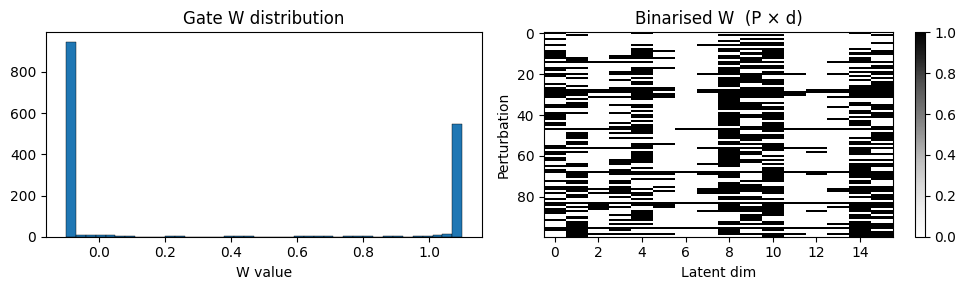

Avg active dims per pert: 6.0 / 16


In [92]:
W = data.uns['results']['W']   # (P, latent_dim)
print(f"W shape: {W.shape}")

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].hist(W.flatten(), bins=40, edgecolor='k', linewidth=0.3)
axes[0].set_title('Gate W distribution')
axes[0].set_xlabel('W value')

W_bin = (W > 0.5).astype(float)
im = axes[1].imshow(W_bin, aspect='auto', cmap='Greys', interpolation='nearest')
axes[1].set_title('Binarised W  (P × d)')
axes[1].set_xlabel('Latent dim')
axes[1].set_ylabel('Perturbation')
plt.colorbar(im, ax=axes[1])
plt.tight_layout()
plt.show()

print(f"Avg active dims per pert: {W_bin.sum(1).mean():.1f} / {W.shape[1]}")

In [93]:
rho_perts = data.uns['results']['rho_perts']
C = z_corr
print(f"rho_corr: {C.shape}  |  perts: {len(rho_perts)}")

rho_corr: (100, 100)  |  perts: 100


In [49]:
np.where(rho_perts == 'PDGFRA')

(array([57]),)

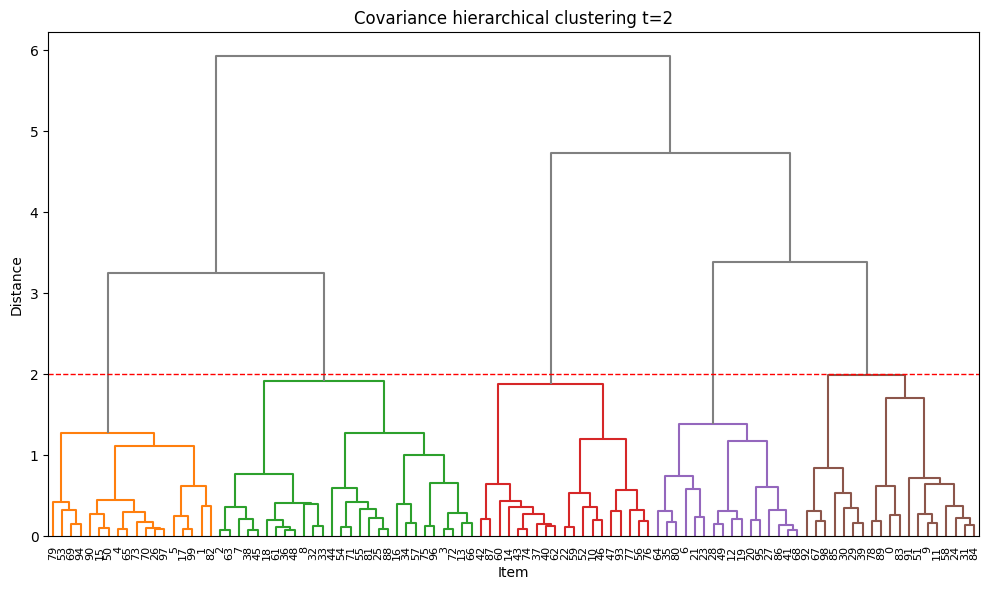

,group
ADCK3,5
ATR,1
AURKB,2
AXL,2
BCR,1
...,...
TTN,4
TYK2,2
WEE1,1
WNK2,5


In [94]:
groups       = slk.tl.cluster_rho(data, t=2, rho_corr=C, show=True)
named_groups = slk.tl.group2name(groups, list(rho_perts))
named_groups

In [43]:
np.where(rho_perts == 'PDGFRA')

(array([57]),)

In [95]:
named_groups[named_groups.index == 'PDGFRA'], named_groups[named_groups.index == 'EPHA2']


(        group
 PDGFRA      2,
        group
 EPHA2      2)

In [45]:
named_groups[named_groups['group'] == 5]

,group
BCR,5
BTK,5
CDKL1,5
MAP4K3,5
MAPKAPK5,5
PKMYT1,5
PRKCI,5
STK33,5
STRADB,5
TGFBR2,5


In [46]:
named_groups[named_groups['group'] == 3]

,group
AXL,3
CDK2,3
CDK3,3
HIPK4,3
MAP3K7,3
MARK1,3
MET,3
PDIK1L,3
PRKCG,3
RPS6KC1,3


In [47]:
named_groups[named_groups['group'] == 3]

,group
AXL,3
CDK2,3
CDK3,3
HIPK4,3
MAP3K7,3
MARK1,3
MET,3
PDIK1L,3
PRKCG,3
RPS6KC1,3


pert_group
1    3746
2    1543
3    3712
4    2968
5    3317
6    3166
7    2436
Name: count, dtype: int64


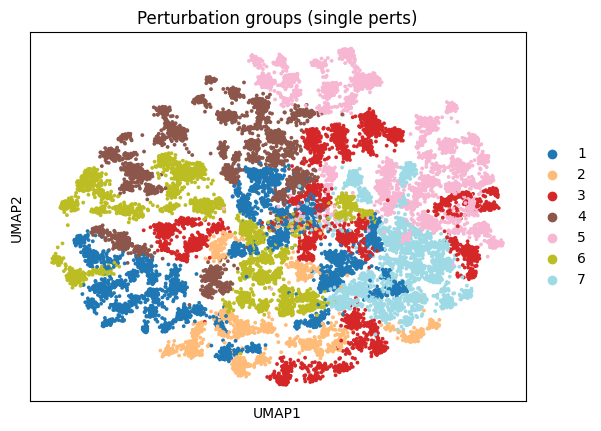

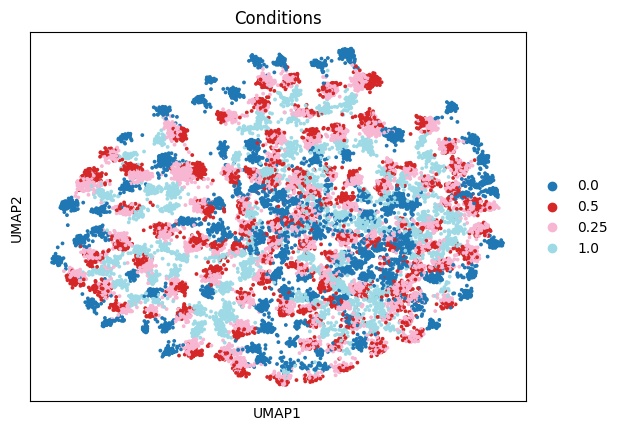

In [73]:
# Colour single-pert UMAP by learned perturbation group
gene_to_group = named_groups['group'].to_dict()
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group).fillna(-1).astype('category')

print(sub.obs['pert_group'].value_counts().sort_index())
sc.pl.umap(sub, color=['pert_group'], title='Perturbation groups (single perts)', palette='tab20', size=30)
sc.pl.umap(sub, color=[c_key], title='Conditions', palette='tab20', size=30)

pert_group
1    5083
2    8163
3    2220
4    3044
Name: count, dtype: int64


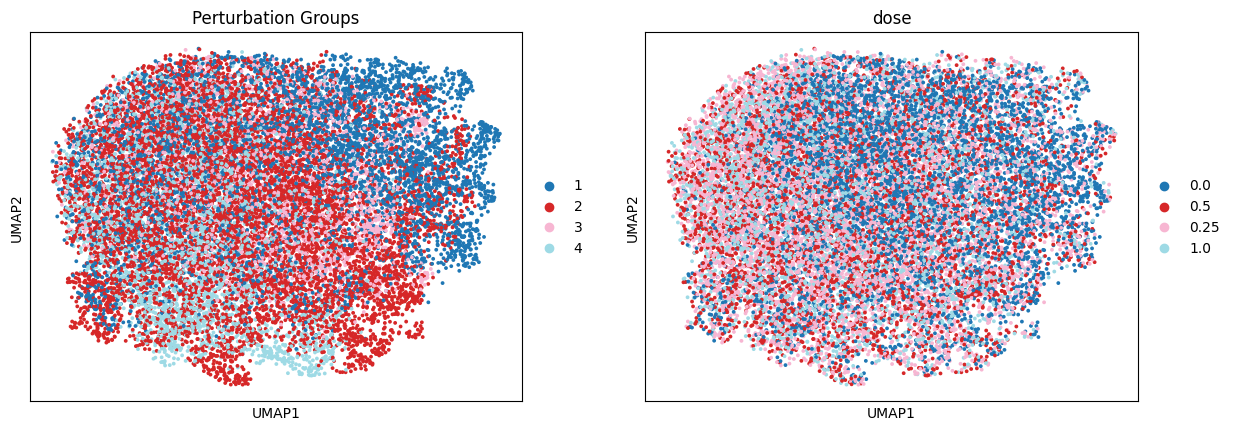

In [46]:
# map perturbation -> group using named_groups (index=gene, column='group')
gene_to_group = named_groups['group'].to_dict()

# assign group to obs based on slk pert key
sub.obs['pert_group'] = sub.obs[p_key].map(gene_to_group)

# mark NTC / unknown perturbations as -1 and ensure integer dtype
sub.obs['pert_group'] = sub.obs['pert_group'].fillna(-1).astype('category')

# quick summary
print(sub.obs['pert_group'].value_counts().sort_index())

sc.pl.umap(sub, color=['pert_group', 'dose'], title='Perturbation Groups', palette='tab20', size=30)

In [28]:
for i in sub.obs.pert_group.unique():
    print(i)
    print(sub[sub.obs.pert_group == i].obs['pert'].value_counts())

5
pert
STK17B      264
TGFBR2      257
STK35       238
CDC42BPA    196
ATR         192
CDK8        176
AXL         169
EPHA2       156
EPHB2       144
BRDT        143
PRPF4B      140
NRBP1       138
KDR         133
CDK2        133
MASTL       130
PRKACG      125
PDGFRA      122
SMG1        121
PRKCG       116
WEE1        111
AURKB        27
Name: count, dtype: int64
1
pert
PRKCZ      541
SPEG       434
MKNK2      427
TTN        408
HIPK4      332
CDKL1      286
MAPK9      267
SCYL2      254
NRBP2      239
DAPK3      234
CSNK1G2    230
MAP4K3     226
PIK3C2A    156
Name: count, dtype: int64
3
pert
GSK3A    344
CDK17    285
PRKD1    282
WNK3     230
BTK      213
PIM2     209
ADCK3    206
NPR2     171
TLK2     121
Name: count, dtype: int64
7
pert
STK33      304
RPS6KA3    304
IRAK1      285
ROCK2      285
MAP3K4     274
RIPK4      266
PDIK1L     257
DAPK2      227
C9orf96    209
JAK1       179
MAP3K5     176
PRKG2      131
Name: count, dtype: int64
6
pert
PASK       333
WNK2       292
SGK

In [29]:
# Print gene symbols per group, one gene per line (no quotation marks)
grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())

for grp in sorted(grouped.index):
    print(f"Group {grp}:")
    for gene in grouped.loc[grp]:
        print(gene)
    print()

Group 1:
CDKL1
CSNK1G2
DAPK3
HIPK4
MAP4K3
MAPK9
MKNK2
NRBP2
PIK3C2A
PRKCZ
SCYL2
SPEG
TTN

Group 2:
CDK3
CSNK2A2
MAPKAPK5
NEK8
NEK9
PRKCI
STK40
TYK2

Group 3:
ADCK3
BTK
CDK17
GSK3A
NPR2
PIM2
PRKD1
TLK2
WNK3

Group 4:
BCR
BUB1B
CDK11A
CDK12
CDK4
EIF2AK3
IRAK3
MAK
MAP3K7
MARK1
NEK4
NTRK3
PRKDC
RIPK2
RPS6KA4
STRADB
TESK1

Group 5:
ATR
AURKB
AXL
BRDT
CDC42BPA
CDK2
CDK8
EPHA2
EPHB2
KDR
MASTL
NRBP1
PDGFRA
PRKACG
PRKCG
PRPF4B
SMG1
STK17B
STK35
TGFBR2
WEE1

Group 6:
MAST4
MET
NPR1
PASK
RIOK2
RPS6KC1
SGK2
WNK2

Group 7:
C9orf96
DAPK2
IRAK1
JAK1
MAP3K4
MAP3K5
PDIK1L
PRKG2
RIPK4
ROCK2
RPS6KA3
STK33

Group 8:
CDKL2
EIF2AK2
ERBB4
MAP3K14
MAP4K1
PEAK1
PIK3CB
PKMYT1
PNCK
STRADA
STYK1
TEX14



/var/tmp/ipykernel_3501253/2222304912.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = named_groups.groupby('group').apply(lambda df: df.index.tolist())


In [30]:
# ── Diagnose why silhouette-based CPI shows flat near-zero scores ─────────────
# With use_conditions=True, the encoder computes:
#   z = z_base(cond)  +  z_delta(x_cell − mean_NTC_x_for_cond)
# z_base is a *global* condition offset — identical for NTC and every perturbation
# in the same condition.  Single-cell z_delta variance overwhelms this shared shift,
# so pairwise silhouettes within each pert are near zero for ALL perts equally.
#
# Fix: pseudobulk mean-z per (pert, cond) then subtract the NTC baseline per
# condition.  This removes the shared z_base(cond) term and exposes any
# pert-specific condition interaction left in the encoder residuals.

p_key = slk.configs.get_config('pert_key')
c_key = slk.configs.get_config('treatment_key')
NTC   = slk.configs.get_config('ntc_label')

z_all    = data.obsm['z']                      # (N, latent_dim)
pert_col = data.obs[p_key].values
cond_col = data.obs[c_key].values
conditions = sorted(np.unique(cond_col), key=float)
perts      = [p for p in np.unique(pert_col) if p != NTC]

# Step 1: pseudobulk mean-z per (pert or NTC, condition)
def mean_z(label, cond, min_cells=3):
    m = (pert_col == label) & (cond_col == cond)
    return z_all[m].mean(0) if m.sum() >= min_cells else None

z_ntc = {c: mean_z(NTC, c) for c in conditions}   # NTC z_base estimate per cond
print("NTC mean-z per condition (should differ if z_base is informative):")
for c1, c2 in zip(conditions[:-1], conditions[1:]):
    if z_ntc[c1] is not None and z_ntc[c2] is not None:
        dist = np.linalg.norm(z_ntc[c1] - z_ntc[c2])
        print(f"  ||NTC z_base({c1}) - z_base({c2})|| = {dist:.3f}")


NTC mean-z per condition (should differ if z_base is informative):
  ||NTC z_base(0.0) - z_base(0.25)|| = 2.147
  ||NTC z_base(0.25) - z_base(0.5)|| = 0.507
  ||NTC z_base(0.5) - z_base(1.0)|| = 0.380


In [31]:
# ── NTC-corrected pseudobulk condition sensitivity ────────────────────────────
# For each pert p: delta[p,c] = mean_z(p,c) - mean_z(NTC,c)
#   delta removes the shared condition offset (z_base) and captures the
#   pert-specific z shift above the NTC baseline for each condition.
# Condition sensitivity = mean pairwise L2 distance of delta across conditions.

from itertools import combinations

records = []
for p in perts:
    deltas = []
    for c in conditions:
        zp = mean_z(p, c)
        zn = z_ntc.get(c)
        if zp is not None and zn is not None:
            deltas.append(zp - zn)
    if len(deltas) < 2:
        continue
    deltas = np.stack(deltas)                              # (n_conds, d)
    mean_delta = deltas.mean(0)
    # mean pairwise L2 distance of delta vectors across conditions
    dists = [np.linalg.norm(deltas[i] - deltas[j])
             for i, j in combinations(range(len(deltas)), 2)]
    records.append({'pert': p, 'cond_sensitivity': np.mean(dists),
                    'n_conds': len(deltas)})

cond_sens = (pd.DataFrame(records)
               .sort_values('cond_sensitivity', ascending=False)
               .reset_index(drop=True))

print(f"Perturbations with coverage in ≥2 conditions: {len(cond_sens)}")
print("\nMost condition-sensitive (expect dose gradient in UMAP):")
print(cond_sens.head(15).to_string(index=False))
print("\nLeast condition-sensitive (expect mixing in UMAP):")
print(cond_sens.tail(15).to_string(index=False))


Perturbations with coverage in ≥2 conditions: 100

Most condition-sensitive (expect dose gradient in UMAP):
   pert  cond_sensitivity  n_conds
  AURKB          2.555460        3
PIK3C2A          2.326494        4
  TEX14          2.207912        4
 MAP4K1          2.028769        4
  BUB1B          2.005481        4
  IRAK1          1.920799        4
 PRKACG          1.783905        4
  MKNK2          1.713557        4
 PKMYT1          1.585098        4
    AXL          1.574687        4
   JAK1          1.564883        4
   TLK2          1.563368        4
   WNK2          1.550211        4
  MARK1          1.526917        4
  CDKL2          1.520808        4

Least condition-sensitive (expect mixing in UMAP):
    pert  cond_sensitivity  n_conds
CDC42BPA          0.995015        4
   GSK3A          0.993779        4
    NPR2          0.984078        4
   STK40          0.978947        4
   HIPK4          0.978433        4
    PNCK          0.975068        4
 EIF2AK2          0.971880  

In [1]:
# ── UMAP: global sensitivity map + per-pert gradient vs mixing panels ─────────
sub = data[data.obs[p_key] != NTC].copy()
sc.pp.neighbors(sub, n_neighbors=15, use_rep='z')
sc.tl.umap(sub)

pert_to_sens = dict(zip(cond_sens['pert'], cond_sens['cond_sensitivity']))
sub.obs['cond_sensitivity'] = sub.obs[p_key].map(pert_to_sens).astype(float)

# --- global view ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc.pl.umap(sub, color='cond_sensitivity', cmap='YlOrRd',
           title='NTC-corrected condition sensitivity (pseudobulk)',
           frameon=False, ax=axes[0], show=False)
sc.pl.umap(sub, color=c_key, title='T-cell dose',
           frameon=False, ax=axes[1], show=False)
plt.tight_layout()
plt.show()

# --- per-pert panels: top/bottom 5 ---
n_show    = 5
top_perts = cond_sens.head(n_show)['pert'].tolist()
bot_perts = cond_sens.tail(n_show)['pert'].tolist()

umap_bg   = sub.obsm['X_umap']
cond_vals = sub.obs[c_key].astype(str).values
dose_order   = sorted(sub.obs[c_key].unique(), key=float)
dose_palette = dict(zip(dose_order, sns.color_palette("YlOrRd", len(dose_order))))

fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
for row, perts_list in enumerate([top_perts, bot_perts]):
    for col, pert in enumerate(perts_list):
        ax = axes[row, col]
        mask  = sub.obs[p_key].values == pert
        score = pert_to_sens.get(pert, np.nan)
        ax.scatter(umap_bg[:, 0], umap_bg[:, 1], c='lightgrey', s=2,
                   linewidths=0, rasterized=True)
        fg_umap = umap_bg[mask]
        colors  = [dose_palette[d] for d in cond_vals[mask]]
        ax.scatter(fg_umap[:, 0], fg_umap[:, 1], c=colors, s=14, linewidths=0)
        ax.set_title(f'{pert}\n(sens={score:.3f})', fontsize=9)
        ax.axis('off')

axes[0, 0].set_ylabel('High condition sensitivity', fontsize=11, labelpad=8)
axes[1, 0].set_ylabel('Low condition sensitivity',  fontsize=11, labelpad=8)

from matplotlib.lines import Line2D
handles = [Line2D([0], [0], marker='o', color='w',
                  markerfacecolor=dose_palette[d], markersize=8, label=f'dose={d}')
           for d in dose_order]
fig.legend(handles=handles, title='T-cell dose', loc='lower center',
           ncol=len(dose_order), bbox_to_anchor=(0.5, -0.02), frameon=False)
plt.suptitle('Condition sensitivity — gradient (top) vs mixing (bottom)', y=1.01, fontsize=13)
plt.tight_layout()
plt.show()


NameError: name 'data' is not defined